In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
import yfinance as yf

tickers = ["TSLA", "BND", "SPY"]

data = {}

for ticker in tickers:
    df = yf.download(
        ticker,
        start="2015-01-01",
        end="2026-07-01",
        auto_adjust=False,
        progress=False
    )
    data[ticker] = df

print(data.keys())

dict_keys(['TSLA', 'BND', 'SPY'])


In [3]:
tsla = data["TSLA"][["Close"]].copy()
tsla.index = pd.to_datetime(tsla.index)
tsla.sort_index(inplace=True)

print(tsla.head())

Price           Close
Ticker           TSLA
Date                 
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


In [4]:
print(data["TSLA"].columns)

MultiIndex([('Adj Close', 'TSLA'),
            (    'Close', 'TSLA'),
            (     'High', 'TSLA'),
            (      'Low', 'TSLA'),
            (     'Open', 'TSLA'),
            (   'Volume', 'TSLA')],
           names=['Price', 'Ticker'])


In [5]:
tsla = data["TSLA"].copy()
tsla.columns = tsla.columns.get_level_values(0)
tsla = tsla[["Close"]]

In [6]:
print(tsla.info())
print(tsla.head())

<class 'pandas.DataFrame'>
DatetimeIndex: 2889 entries, 2015-01-02 to 2026-06-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2889 non-null   float64
dtypes: float64(1)
memory usage: 45.1 KB
None
Price           Close
Date                 
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


In [7]:
train = tsla.loc["2015-01-01":"2024-12-31"].copy()
test  = tsla.loc["2025-01-01":"2026-06-30"].copy()

train_close = train["Close"].values.reshape(-1, 1)
test_close  = test["Close"].values.reshape(-1, 1)

In [8]:
tsla = data["TSLA"][["Close"]].copy()
tsla.index = pd.to_datetime(tsla.index)
tsla.sort_index(inplace=True)

print(tsla.head())

Price           Close
Ticker           TSLA
Date                 
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_close)
test_scaled = scaler.transform(test_close)

In [10]:
def create_sequences(data, window_size=60):
    X, y = [], []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y

window_size = 60

X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test   = create_sequences(test_scaled, window_size)

In [11]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape)
print(X_test.shape)

(2456, 60, 1)
(313, 60, 1)


In [12]:
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
model.add(Dropout(0.2))

model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1))

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 69s 79ms/step - loss: 0.0057 - val_loss: 0.0029
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0021 - val_loss: 0.0065
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0024 - val_loss: 0.0027
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0019 - val_loss: 0.0035
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0015 - val_loss: 0.0023
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0015 - val_loss: 0.0021
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 9/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 10/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 11/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 12/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.

In [15]:
predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


In [16]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [17]:
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [23]:
%whos

Variable           Type            Data/Info
--------------------------------------------
Dense              type            <class 'keras.src.layers.core.dense.Dense'>
Dropout            type            <class 'keras.src.layers.<...>ization.dropout.Dropout'>
LSTM               type            <class 'keras.src.layers.rnn.lstm.LSTM'>
MinMaxScaler       type            <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
Sequential         type            <class 'keras.src.models.sequential.Sequential'>
X_test             ndarray         313x60x1: 18780 elems, type `float64`, 150240 bytes (146.71875 kb)
X_train            ndarray         2456x60x1: 147360 elems, type `float64`, 1178880 bytes (1.124267578125 Mb)
actual             ndarray         313x1: 313 elems, type `float64`, 2504 bytes
create_sequences   function        <function create_sequences at 0x0000024CA04C1580>
data               dict            n=3
df                 DataFrame       Shape: (2889, 6)
history            Hi

In [18]:
test_index = test.index[window_size:]

In [19]:
print(len(test_index))
print(actual.shape)
print(predictions.shape)

313
(313, 1)
(313, 1)


In [20]:
actual = actual.flatten()
predictions = predictions.flatten()

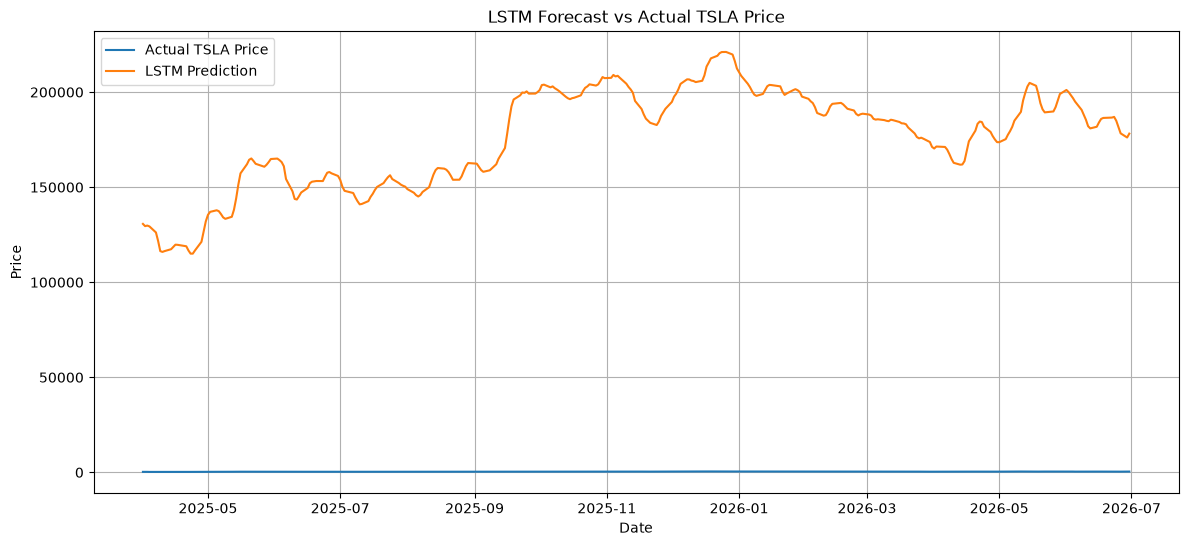

In [21]:
plt.figure(figsize=(14,6))

plt.plot(test_index, actual, label="Actual TSLA Price")
plt.plot(test_index, predictions, label="LSTM Prediction")

plt.title("LSTM Forecast vs Actual TSLA Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

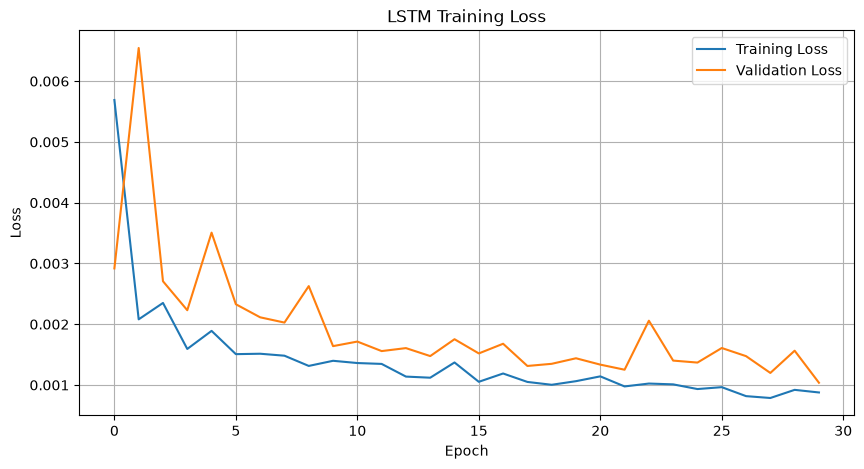

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [23]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train_close,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=None,                  # Determine differencing automatically
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    information_criterion="aic"
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=1.90 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.34 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 3.987 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        23:57:27   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

In [24]:
best_order = auto_model.order

print("Best ARIMA order:", best_order)

Best ARIMA order: (0, 1, 0)


In [25]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train_close, order=best_order)
arima_fit = arima.fit()

In [26]:
from itertools import product
from statsmodels.tsa.arima.model import ARIMA

p = range(0,4)
d = range(0,3)
q = range(0,4)

best_aic = float("inf")
best_order = None

for order in product(p,d,q):
    try:
        model = ARIMA(train_close, order=order)
        result = model.fit()

        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order

    except:
        continue

print("Best Order:", best_order)
print("Best AIC:", best_aic)

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization faile

Best Order: (2, 2, 3)
Best AIC: 16345.628622458518


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_lstm(units1, units2, learning_rate):

    model = Sequential()

    model.add(
        LSTM(
            units1,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(Dropout(0.2))

    model.add(
        LSTM(
            units2
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(1))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

In [28]:
architectures = [
    (32,16),
    (64,32),
    (128,64)
]

epochs_list = [20,30,50]

batch_sizes = [16,32,64]

learning_rates = [0.001,0.0005]

In [29]:
results = []

for units1, units2 in architectures:

    for epochs in epochs_list:

        for batch in batch_sizes:

            for lr in learning_rates:

                print(f"Training: {units1}-{units2}, Epochs={epochs}, Batch={batch}, LR={lr}")

                model = build_lstm(
                    units1,
                    units2,
                    lr
                )

                history = model.fit(
                    X_train,
                    y_train,
                    epochs=epochs,
                    batch_size=batch,
                    validation_split=0.1,
                    verbose=0
                )

                val_loss = min(history.history["val_loss"])

                results.append({
                    "Layer1": units1,
                    "Layer2": units2,
                    "Epochs": epochs,
                    "Batch Size": batch,
                    "Learning Rate": lr,
                    "Validation Loss": val_loss
                })

Training: 32-16, Epochs=20, Batch=16, LR=0.001


C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training: 32-16, Epochs=20, Batch=16, LR=0.0005
Training: 32-16, Epochs=20, Batch=32, LR=0.001
Training: 32-16, Epochs=20, Batch=32, LR=0.0005
Training: 32-16, Epochs=20, Batch=64, LR=0.001
Training: 32-16, Epochs=20, Batch=64, LR=0.0005
Training: 32-16, Epochs=30, Batch=16, LR=0.001
Training: 32-16, Epochs=30, Batch=16, LR=0.0005
Training: 32-16, Epochs=30, Batch=32, LR=0.001
Training: 32-16, Epochs=30, Batch=32, LR=0.0005
Training: 32-16, Epochs=30, Batch=64, LR=0.001
Training: 32-16, Epochs=30, Batch=64, LR=0.0005
Training: 32-16, Epochs=50, Batch=16, LR=0.001
Training: 32-16, Epochs=50, Batch=16, LR=0.0005
Training: 32-16, Epochs=50, Batch=32, LR=0.001
Training: 32-16, Epochs=50, Batch=32, LR=0.0005
Training: 32-16, Epochs=50, Batch=64, LR=0.001
Training: 32-16, Epochs=50, Batch=64, LR=0.0005
Training: 64-32, Epochs=20, Batch=16, LR=0.001
Training: 64-32, Epochs=20, Batch=16, LR=0.0005
Training: 64-32, Epochs=20, Batch=32, LR=0.001
Training: 64-32, Epochs=20, Batch=32, LR=0.0005
Tr

In [30]:
results = pd.DataFrame(results)

results.sort_values(
    "Validation Loss"
).head(10)

,Layer1,Layer2,Epochs,Batch Size,Learning Rate,Validation Loss
48,128,64,50,16,0.0010,0.000534
30,64,32,50,16,0.0010,0.000633
42,128,64,30,16,0.0010,0.000689
49,128,64,50,16,0.0005,0.000700
50,128,64,50,32,0.0010,0.000705
12,32,16,50,16,0.0010,0.000795
32,64,32,50,32,0.0010,0.000829
43,128,64,30,16,0.0005,0.000840
36,128,64,20,16,0.0010,0.000848
31,64,32,50,16,0.0005,0.000851


In [31]:
best_model = build_lstm(
    units1=64,
    units2=32,
    learning_rate=0.001
)

history = best_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1
)

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 97ms/step - loss: 0.0081 - val_loss: 0.0030
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0023 - val_loss: 0.0031
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - loss: 0.0018 - val_loss: 0.0025
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0018 - val_loss: 0.0023
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0016 - val_loss: 0.0021
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 9/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0014 - val_loss: 0.0019
Epoch 10/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 11/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0013 - val_loss: 0.0017
Epoch 12/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.

In [32]:
predictions = best_model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 44s 808ms/step


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(actual, predictions)
)

mae = mean_absolute_error(
    actual,
    predictions
)

print("RMSE:", rmse)
print("MAE :", mae)

RMSE: 15.900964194899972
MAE : 12.443202204597643


In [34]:
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

In [35]:
def evaluate_model(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = mean_absolute_percentage_error(
        actual,
        predicted
    ) * 100

    return mae, rmse, mape

In [37]:
%whos

Variable                         Type                   Data/Info
-----------------------------------------------------------------
ARIMA                            type                   <class 'statsmodels.tsa.arima.model.ARIMA'>
Adam                             type                   <class 'keras.src.optimizers.adam.Adam'>
Dense                            type                   <class 'keras.src.layers.core.dense.Dense'>
Dropout                          type                   <class 'keras.src.layers.<...>ization.dropout.Dropout'>
LSTM                             type                   <class 'keras.src.layers.rnn.lstm.LSTM'>
MinMaxScaler                     type                   <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
Sequential                       type                   <class 'keras.src.models.sequential.Sequential'>
X_test                           ndarray                313x60x1: 18780 elems, type `float64`, 150240 bytes (146.71875 kb)
X_train               

In [39]:
print(arima_fit.model.order)

(1, 1, 1)


In [40]:
forecast = arima_fit.forecast(steps=len(test_close))

In [41]:
print(type(forecast))
print(len(forecast))
print(forecast[:5])

<class 'numpy.ndarray'>
373
[403.92340286 403.92306523 403.9230666  403.92306659 403.92306659]


In [42]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA
arima_model = ARIMA(train_close.squeeze(), order=(1,1,1))
arima_fit = arima_model.fit()

# Forecast
forecast = arima_fit.forecast(steps=len(test_close))

In [43]:
arima_mae, arima_rmse, arima_mape = evaluate_model(
    test_close,
    forecast
)

print("ARIMA")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA
MAE : 54.357309877127236
RMSE: 70.48678727230543
MAPE: 17.2129006106114


In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_close.flatten(),
    order=order,              # e.g. (1,1,1)
    seasonal_order=(1,1,1,5), # replace if you selected a different seasonal order
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 2516
Model:             SARIMAX(3, 2, 3)x(1, 1, [1], 5)   Log Likelihood               -8158.777
Date:                             Mon, 06 Jul 2026   AIC                          16335.555
Time:                                     06:06:45   BIC                          16387.971
Sample:                                          0   HQIC                         16354.584
                                            - 2516                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9002      0.347     -2.592      0.010      -1.581      -0.220
ar.L2         -0.3783      

In [46]:
sarima_forecast = sarima_fit.forecast(steps=len(test_close))
sarima_forecast = np.asarray(sarima_forecast).flatten()

In [47]:
sarima_mae, sarima_rmse, sarima_mape = evaluate_model(
    test_close,
    sarima_forecast
)

print("SARIMA")
print("MAE :", sarima_mae)
print("RMSE:", sarima_rmse)
print("MAPE:", sarima_mape)

SARIMA
MAE : 106.79802925524926
RMSE: 118.49787680610312
MAPE: 31.561886201306628


In [48]:
lstm_actual = actual.flatten()

lstm_pred = predictions.flatten()

lstm_mae, lstm_rmse, lstm_mape = evaluate_model(
    lstm_actual,
    lstm_pred
)

print("LSTM")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)

LSTM
MAE : 12.443202204597643
RMSE: 15.900964194899972
MAPE: 3.4038933616039357


In [49]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "ARIMA",
        "SARIMA",
        "LSTM"
    ],

    "MAE":[
        arima_mae,
        sarima_mae,
        lstm_mae
    ],

    "RMSE":[
        arima_rmse,
        sarima_rmse,
        lstm_rmse
    ],

    "MAPE (%)":[
        arima_mape,
        sarima_mape,
        lstm_mape
    ]

})

results.sort_values("RMSE")

,Model,MAE,RMSE,MAPE (%)
2,LSTM,12.443202,15.900964,3.403893
0,ARIMA,54.357310,70.486787,17.212901
1,SARIMA,106.798029,118.497877,31.561886


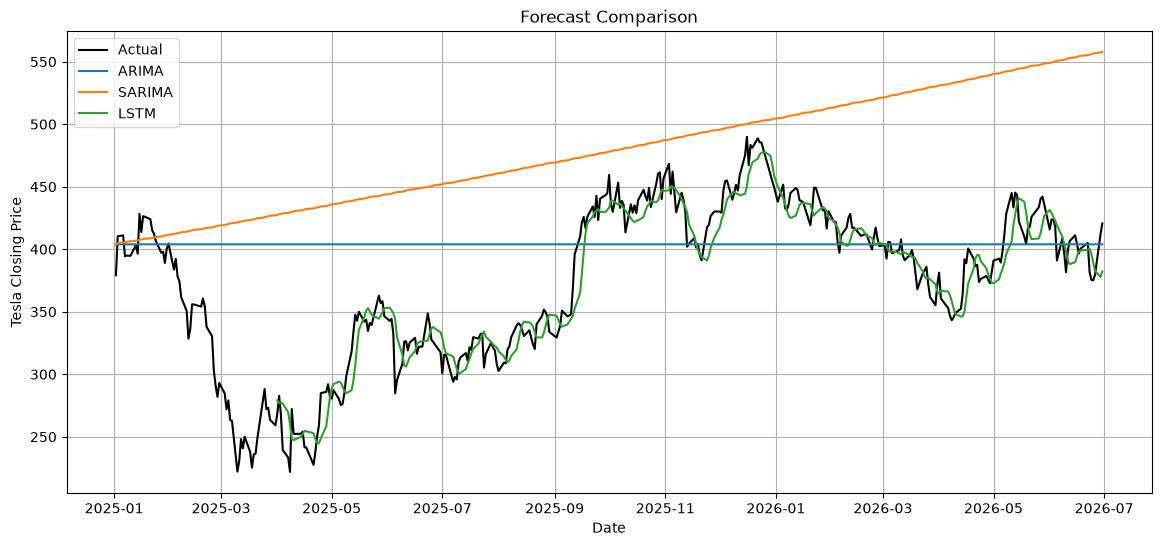

In [51]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Actual values
plt.plot(
    test.index,
    test_close.flatten(),
    label="Actual",
    color="black"
)

# ARIMA
plt.plot(
    test.index,
    np.asarray(forecast).flatten(),
    label="ARIMA"
)

# SARIMA (only if it exists)
if "sarima_forecast" in globals():
    plt.plot(
        test.index,
        np.asarray(sarima_forecast).flatten(),
        label="SARIMA"
    )

# LSTM
plt.plot(
    test_index,
    predictions.flatten(),
    label="LSTM"
)

plt.title("Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Tesla Closing Price")
plt.legend()
plt.grid(True)
plt.show()